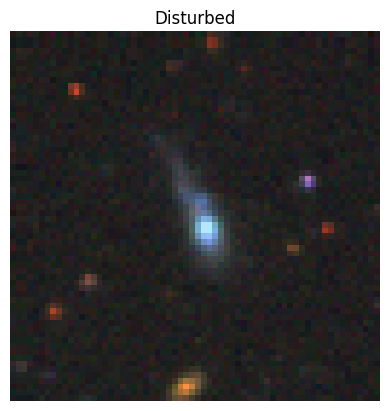

In [3]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

# Class names
CLASS_NAMES = [
    'Disturbed', 'Merging', 'Round Smooth', 'In-between Smooth',
    'Cigar Smooth', 'Barred Spiral', 'Unbarred Tight Spiral',
    'Unbarred Loose Spiral', 'Edge-on no Bulge', 'Edge-on with Bulge'
]

# Load dataset
with h5py.File('Galaxy10_DECals_64x64.h5', 'r') as F:
    images = np.array(F['images'])   # shape: (17736, 64, 64, 3)
    labels = np.array(F['ans'])      # integer labels 0-9

# Display galaxy 27
plt.imshow(images[27] / 255.0)
plt.title(CLASS_NAMES[labels[27]])
plt.axis('off')
plt.show()

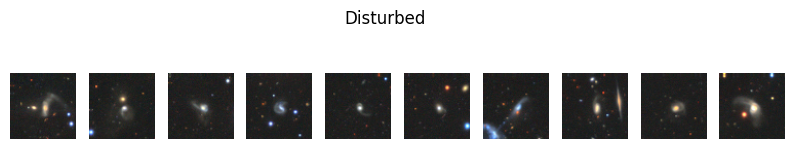

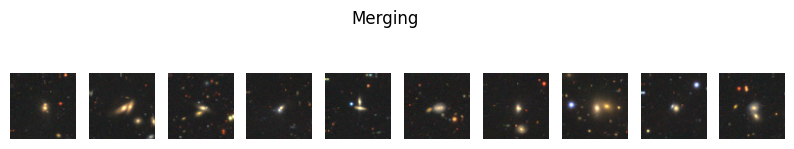

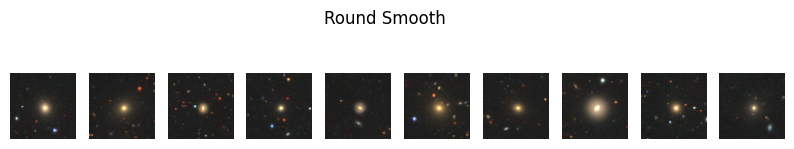

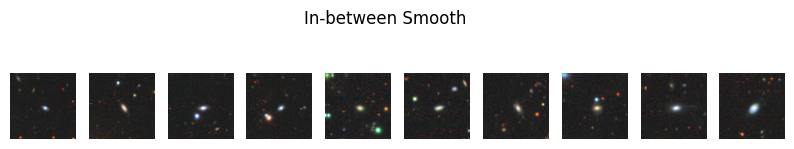

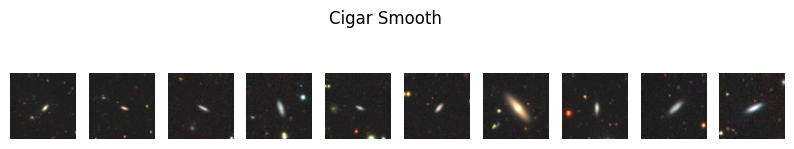

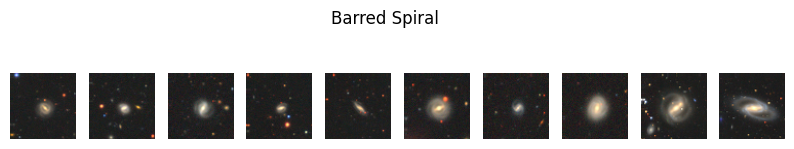

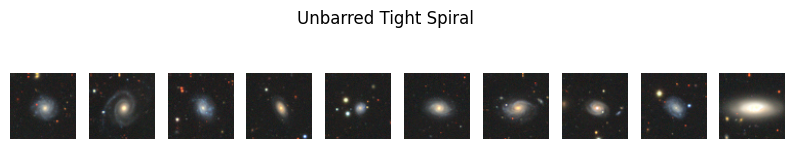

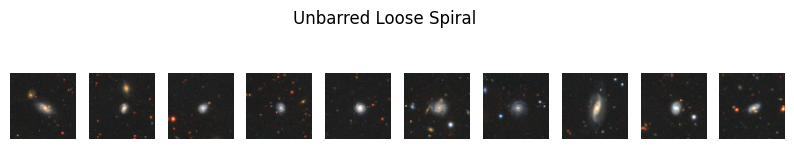

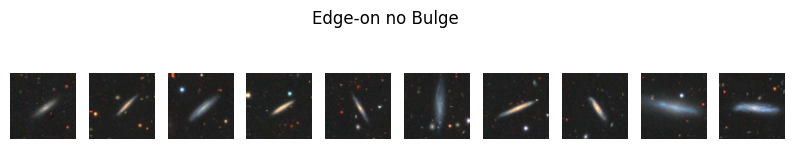

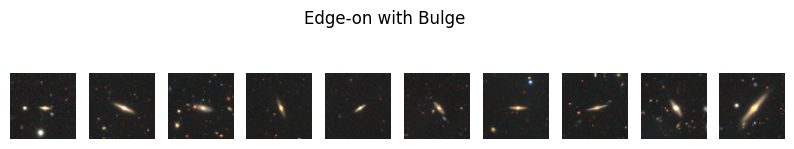

In [4]:
for i in range(10):
    idx = np.where(labels == i)[0]
    plt.figure(figsize=(10, 2))
    for j in range(10):
        plt.subplot(1, 10, j+1)
        plt.imshow(images[idx[j]] / 255.0)
        plt.axis('off')
    plt.suptitle(CLASS_NAMES[i])
    plt.show()

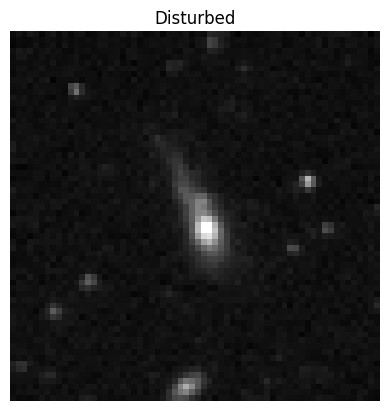

In [5]:
gray_images = np.mean(images, axis=-1)  # shape: (17736, 64, 64)
plt.imshow(gray_images[27], cmap='gray')
plt.title(CLASS_NAMES[labels[27]])
plt.axis('off')
plt.show()

In [6]:
shape = gray_images.shape
print(f"Shape of grayscale images: {shape}")

Shape of grayscale images: (17736, 64, 64)


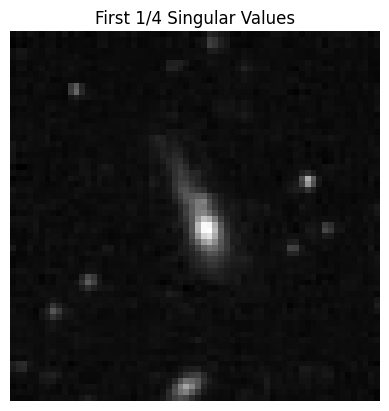

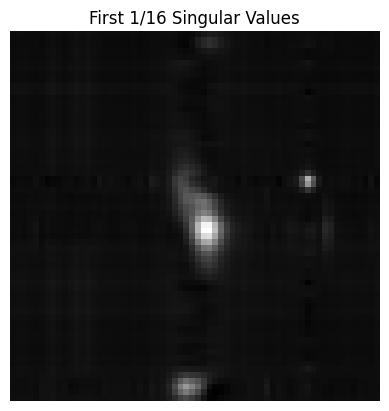

In [16]:
img = gray_images[27]  # shape (64, 64)
U, S, Vt = np.linalg.svd(img, full_matrices=False)

k = len(S) // 4
img_1_4 = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]
plt.imshow(img_1_4, cmap="gray")
plt.title("First 1/4 Singular Values")  
plt.axis('off')
plt.show()
k = len(S) // 16
img_1_16 = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]
plt.imshow(img_1_16, cmap="gray")
plt.title("First 1/16 Singular Values")
plt.axis('off')
plt.show()


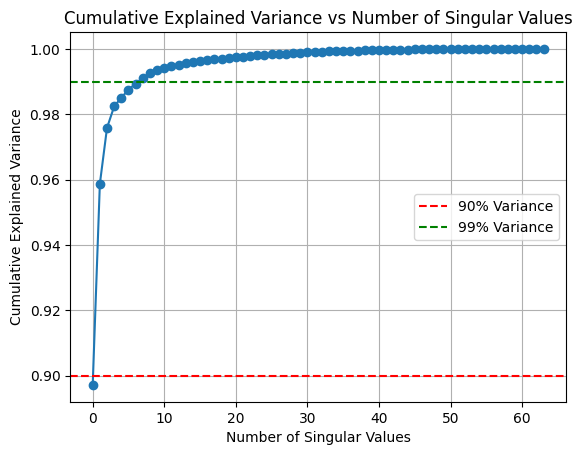

Number of singular values needed to explain 99% variance: 8
Number of singular values needed to explain 90% variance: 2


In [17]:
explained_variance = S**2
fractional_variance = explained_variance / np.sum(explained_variance)
cumulative_variance = np.cumsum(fractional_variance)
plt.plot(cumulative_variance, marker='o')   
plt.axhline(0.9, color='r', linestyle='--', label='90% Variance')
plt.axhline(0.99, color='g', linestyle='--', label='99% Variance')
plt.xlabel('Number of Singular Values')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance vs Number of Singular Values')
plt.legend()
plt.grid()
plt.show()
k_99 = np.argmax(cumulative_variance >= 0.99) + 1 
print(f"Number of singular values needed to explain 99% variance: {k_99}")
k_90 = np.argmax(cumulative_variance >= 0.90) + 1 
print(f"Number of singular values needed to explain 90% variance: {k_90}")

In [9]:
w_1 = 2.858
median = S[31]  # 32nd singular value (index 31)
print(f"32nd singular value: {median:.3f}")
index = 0
for sigma in S:
    index += 1
    if sigma > w_1 * median:
        print(f"{index}. Singular value {sigma:.3f} is larger than 2.858 * {median:.3f}")
    else:
        break   

32nd singular value: 23.668
1. Singular value 2239.678 is larger than 2.858 * 23.668
2. Singular value 586.648 is larger than 2.858 * 23.668
3. Singular value 309.465 is larger than 2.858 * 23.668
4. Singular value 191.425 is larger than 2.858 * 23.668
5. Singular value 123.098 is larger than 2.858 * 23.668
6. Singular value 115.918 is larger than 2.858 * 23.668
7. Singular value 103.269 is larger than 2.858 * 23.668
8. Singular value 96.053 is larger than 2.858 * 23.668
9. Singular value 89.299 is larger than 2.858 * 23.668
10. Singular value 71.305 is larger than 2.858 * 23.668


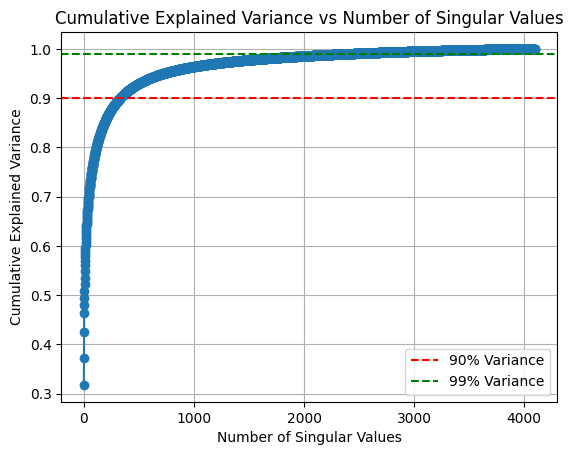

Number of singular values needed to explain 99% variance: 2387
Number of singular values needed to explain 90% variance: 329


In [18]:
flat_x = gray_images.reshape(gray_images.shape[0], -1)  # shape: (17736, 4096)
xmean = flat_x.mean(axis=0)
xcentered = flat_x - xmean
U, S, Vt = np.linalg.svd(xcentered, full_matrices=False)
explained_variance = S**2
fractional_variance = explained_variance / np.sum(explained_variance)
cumulative_variance = np.cumsum(fractional_variance)
plt.plot(cumulative_variance, marker='o')   
plt.axhline(0.9, color='r', linestyle='--', label='90% Variance')
plt.axhline(0.99, color='g', linestyle='--', label='99% Variance')
plt.xlabel('Number of Singular Values')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance vs Number of Singular Values')
plt.legend()
plt.grid()
plt.show()
k_99 = np.argmax(cumulative_variance >= 0.99) + 1 
print(f"Number of singular values needed to explain 99% variance: {k_99}")
k_90 = np.argmax(cumulative_variance >= 0.90) + 1
print(f"Number of singular values needed to explain 90% variance: {k_90}")


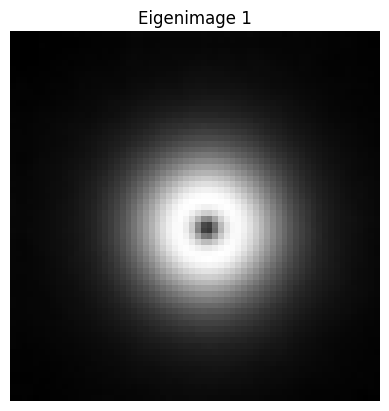

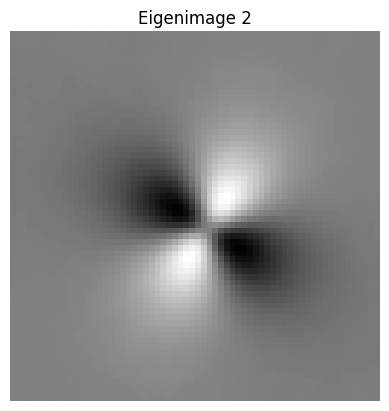

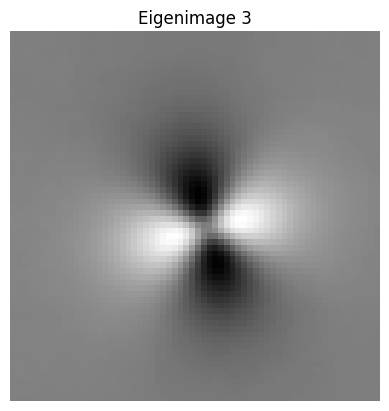

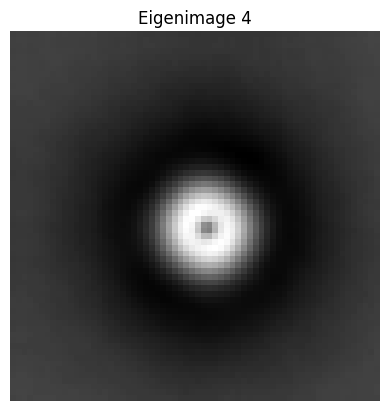

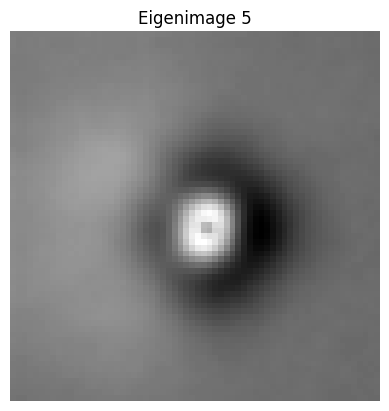

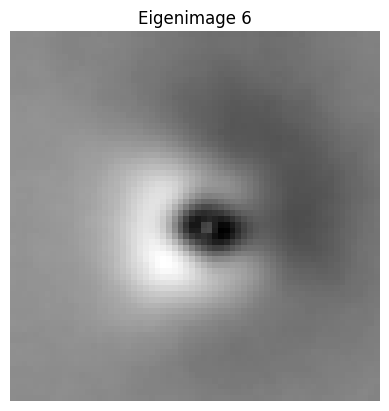

In [11]:
#eigenimages 
eigenimages = Vt[:6, :].reshape((6, 64, 64))
for i in range(6):
    plt.imshow(eigenimages[i], cmap='gray')
    plt.title(f"Eigenimage {i+1}")
    plt.axis('off')
    plt.show()

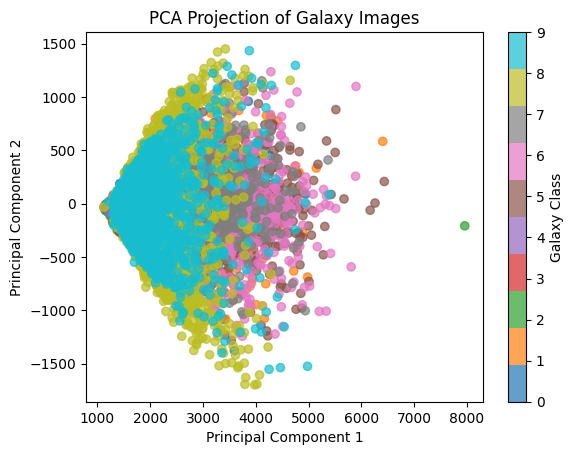

In [15]:
V2 = Vt[:2, :].T      
Z =  flat_x @ V2       
plt.scatter(Z[:, 0], Z[:, 1], c=labels, cmap='tab10', alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Projection of Galaxy Images')
plt.colorbar(ticks=range(10), label='Galaxy Class')
plt.show()   

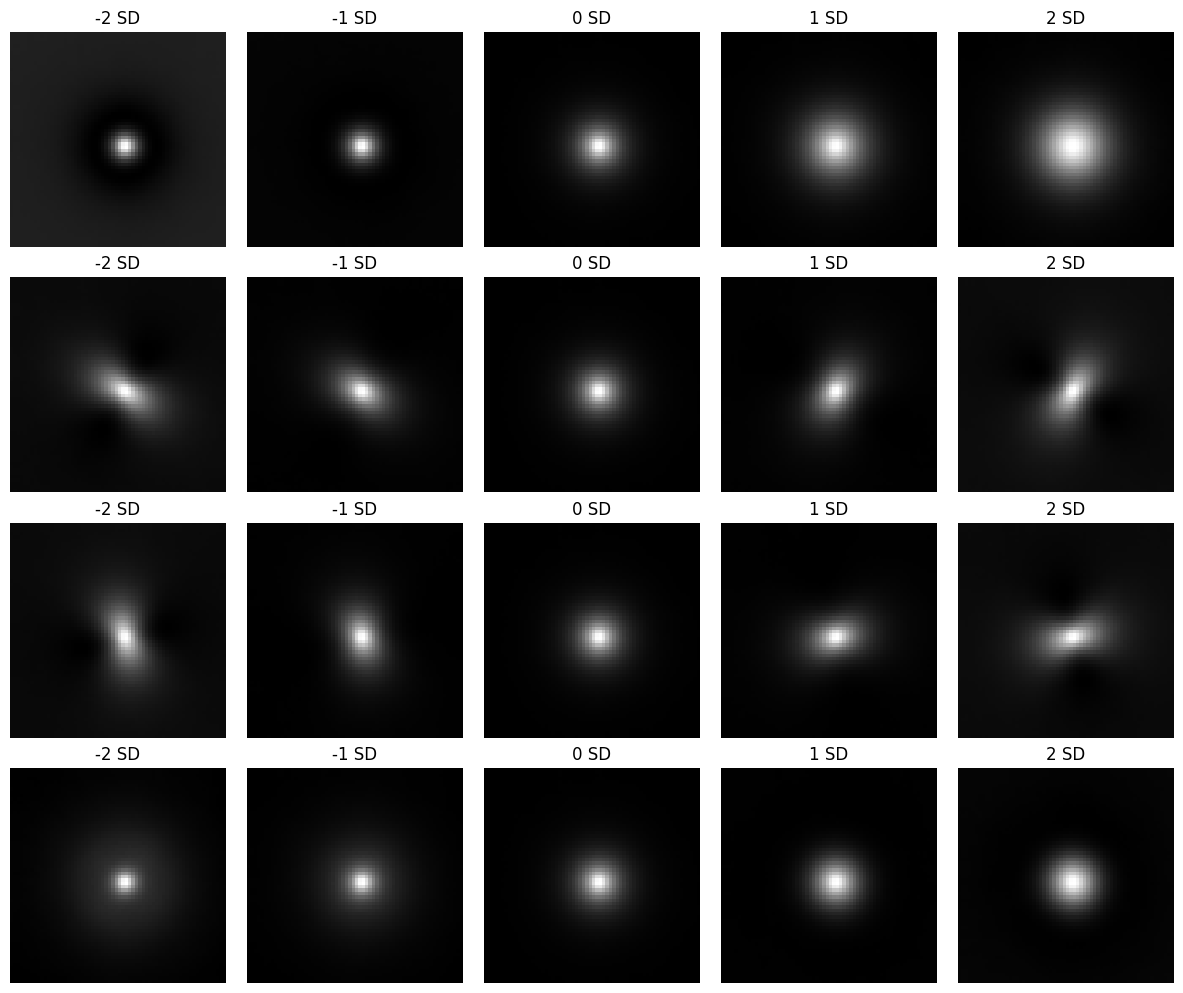

In [25]:
v4 = Vt[:4, :].T
Z4 = xcentered @ v4
sds = np.std(Z4, axis=0)

steps = [-2, -1, 0, 1, 2]

fig, axes = plt.subplots(4, 5, figsize=(12, 10))

for j in range(4):
    for i, a in enumerate(steps):
        z = np.zeros(4)
        z[j] = a * sds[j]

        xhat = xmean + v4 @ z
        img = xhat.reshape(64, 64)

        axes[j, i].imshow(img, cmap='gray')
        axes[j, i].axis('off')
        axes[j, i].set_title(f'{a} SD')

for j in range(4):
    axes[j, 0].set_ylabel(f'PC{j+1}', rotation=90, size=12)

plt.tight_layout()
plt.show()
